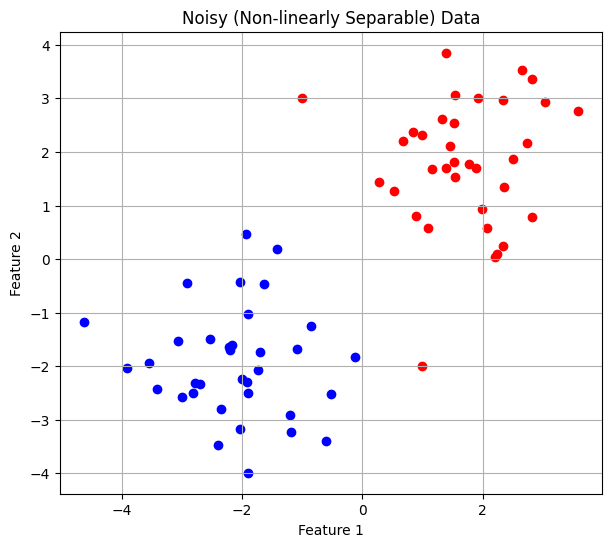

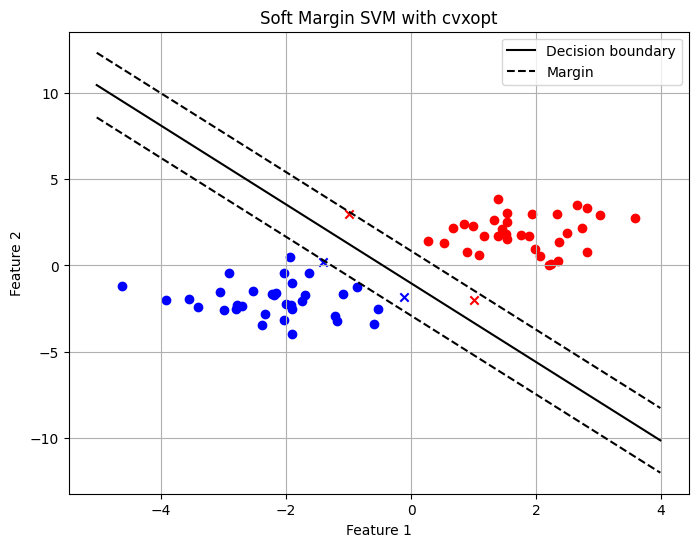

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers

# --- Generate Non-perfectly Separable Dataset ---
np.random.seed(42)
X_pos = np.random.randn(35, 2) + [2, 2]
X_neg = np.random.randn(35, 2) + [-2, -2]
X = np.vstack((X_pos, X_neg))
y = np.hstack((np.ones(35), -1 * np.ones(35)))

# Add noise to make it non-separable
X[10] = [-1, 3]
X[25] = [1, -2]

# --- Plot Function ---
def plot_data(X, y):
    plt.figure(figsize=(7, 6))
    for i in range(len(y)):
        color = 'r' if y[i] == 1 else 'b'
        plt.scatter(X[i][0], X[i][1], color=color)
    plt.title("Noisy (Non-linearly Separable) Data")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()

plot_data(X, y)

def soft_margin_svm(X, y, C=1.0):
    n_samples = X.shape[0]

    # Compute the Gram matrix: K[i,j] = x_i . x_j
    K = np.dot(X, X.T)

    # QP parameters
    P = matrix(np.outer(y, y) * K)
    q = matrix(-np.ones(n_samples))
    G = matrix(np.vstack([-np.eye(n_samples), np.eye(n_samples)]))
    h = matrix(np.hstack([np.zeros(n_samples), np.ones(n_samples) * C]))
    A = matrix(y.reshape(1, -1).astype(float))
    b = matrix(0.0)

    solvers.options['show_progress'] = False
    sol = solvers.qp(P, q, G, h, A, b)
    alpha = np.ravel(sol['x'])

    # Support vectors have non-zero lagrange multipliers
    sv = (alpha > 1e-5)
    alpha_sv = alpha[sv]
    X_sv = X[sv]
    y_sv = y[sv]

    # Compute w
    w = np.sum(alpha_sv[:, np.newaxis] * y_sv[:, np.newaxis] * X_sv, axis=0)

    # Compute b using any support vector
    b = np.mean([y_k - np.dot(w, x_k) for (x_k, y_k) in zip(X_sv, y_sv)])

    return w, b, alpha, sv

w, b, alpha, sv = soft_margin_svm(X, y, C=1.0)
def plot_decision_boundary(X, y, w, b, sv):
    plt.figure(figsize=(8, 6))
    for i in range(len(y)):
        color = 'r' if y[i] == 1 else 'b'
        plt.scatter(X[i][0], X[i][1], color=color, marker='o' if not sv[i] else 'x')

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 50)
    yy = (-w[0] * xx - b) / w[1]

    # Margin lines
    margin = 1 / np.linalg.norm(w)
    yy_down = yy - np.sqrt(1 + (w[0]/w[1])**2) * margin
    yy_up = yy + np.sqrt(1 + (w[0]/w[1])**2) * margin

    plt.plot(xx, yy, 'k-', label='Decision boundary')
    plt.plot(xx, yy_down, 'k--', label='Margin')
    plt.plot(xx, yy_up, 'k--')

    plt.title("Soft Margin SVM with cvxopt")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True)
    plt.show()
plot_decision_boundary(X, y, w, b, sv)

Epoch 0: dist = 0.0350


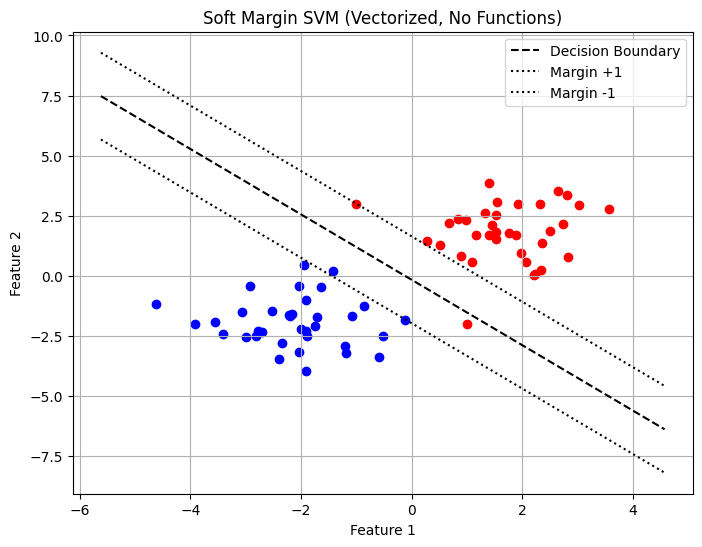

In [7]:
m = X.shape[0]
w = np.zeros(X.shape[1])
b = 0
lr = 0.001
epochs = 100
for epoch in range(epochs):
    y_pred = y*(X@w.T+b)
    constrant = y_pred<1
    x_c = X[constrant]
    y_c = y[constrant]
    if len(y_c)>0:
        dw = np.sum(y_c[:, np.newaxis] * x_c, axis=0)
        db = np.sum(y_c)
        w += lr*dw
        b += lr*db
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: dist = {np.dot(w, w):.4f}")

plt.figure(figsize=(8, 6))
for i in range(len(y)):
    color = 'r' if y[i] == 1 else 'b'
    plt.scatter(X[i][0], X[i][1], color=color)

x_vals = np.linspace(np.min(X[:, 0]) - 1, np.max(X[:, 0]) + 1, 100)
y_vals = -(w[0] * x_vals + b) / w[1]
x2_margin_pos = -(w[0]*x_vals + b - 1) / w[1]
x2_margin_neg = -(w[0]*x_vals + b + 1) / w[1]
plt.plot(x_vals, y_vals, 'k--', label='Decision Boundary')
plt.plot(x_vals, x2_margin_pos, 'k:', label="Margin +1")
plt.plot(x_vals, x2_margin_neg, 'k:', label="Margin -1")
plt.title("Soft Margin SVM (Vectorized, No Functions)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.legend()
plt.show()